In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [43]:
pd.set_option({
    "display.max_rows": None, 
    "display.max_columns": None,
    "display.max_colwidth": None
})

In [2]:
df = pd.read_csv("Russian_Demography_1990_2017.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          2380 non-null   int64  
 1   region        2380 non-null   str    
 2   npg           2317 non-null   float64
 3   birth_rate    2317 non-null   float64
 4   death_rate    2315 non-null   float64
 5   gdw           2330 non-null   float64
 6   urbanization  2330 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 130.3 KB


Birth rate -- the number of live births per 1,000 people in a population in a given year.

Death rate -- the number of deaths per 1,000 people in a population in a given year.

NPG (Natural Population Growth) -- the difference between the birth rate and the death rate in a population.

```NPG = birth rate − death rate```

GDW (General Demographic Weight) -- the ratio of the population of non-working age to the population of working age, expressed per 100 people of working age.

```GDW = (Population of non-working age / Population of working age) × 100```

# Task 1

Test the hypothesis that the mean birth rates in Russia were equal in 2015, 2016, and 2017. The data are assumed to be normally distributed.

In [4]:
years = [2015, 2016, 2017]

birth_rate = {}

for year in years:
    birth_rate[year] = df.loc[df["year"] == year, "birth_rate"]
    print(f"Year {year}: \
        \n\t count: {birth_rate[year].count()} \
        \n\t count nans: {birth_rate[year].isna().sum()} \
    ")

Year 2015:         
	 count: 85         
	 count nans: 0     
Year 2016:         
	 count: 85         
	 count nans: 0     
Year 2017:         
	 count: 85         
	 count nans: 0     


To perform a one-way analysis of variance (one-way ANOVA), we need to check whether the variances are equal across all three populations. We use Bartlett's test to test the equality of several variances.

We can see that the sample sizes are equal. Although equal sample sizes are not required for Bartlett's test, they are advantageous for the precision and robustness of the ANOVA.

In [45]:
bartlett_result = stats.bartlett(*birth_rate.values())
print(bartlett_result)

BartlettResult(statistic=np.float64(0.6594033534095636), pvalue=np.float64(0.7191382371232273))


The Bartlett test statistic is 0.659, with a p-value of 0.719. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis that the population variances are equal. Therefore, there is no statistically significant evidence of a difference in the variances.

Since normality is an assumption of one-way ANOVA, we inspected Q-Q plots for each year. The points lie approximately along the reference line, suggesting that the distributions do not substantially deviate from normality.

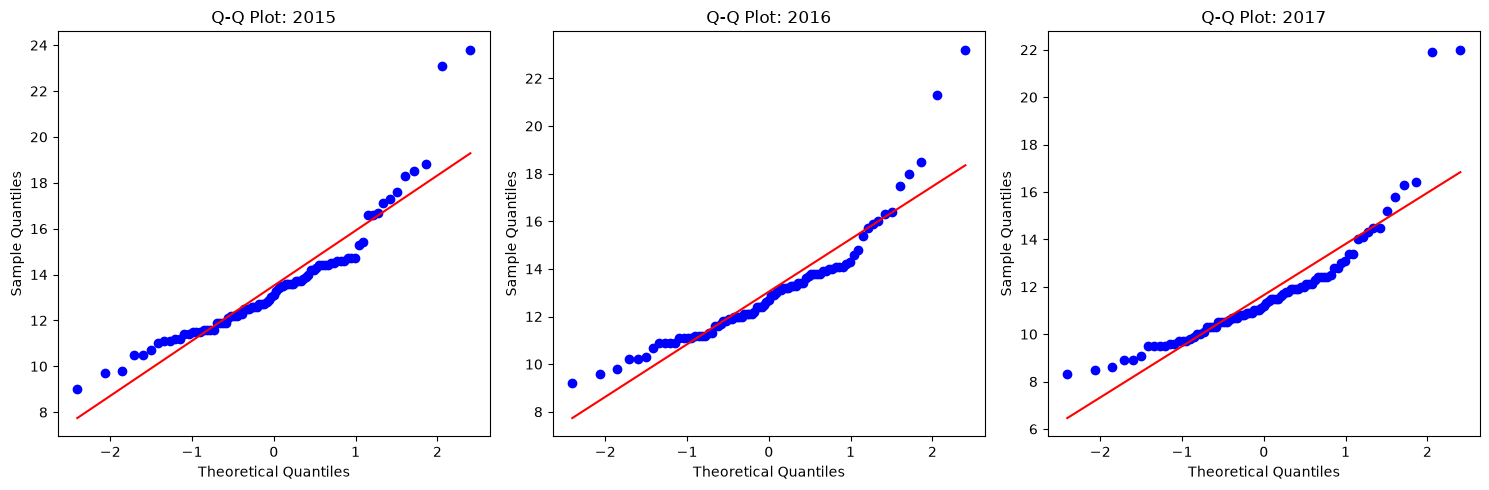

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, year in zip(axes, years):
    stats.probplot(birth_rate[year], dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {year}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

In [46]:
anova_result = stats.f_oneway(*birth_rate.values())
print(anova_result)

F_onewayResult(statistic=np.float64(13.83228246166574), pvalue=np.float64(1.9959534521522416e-06))


The ANOVA test gives an F-statistic of 13.83 and a p-value of approximately 0.000002. Since the p-value is much smaller than 0.05, we reject the null hypothesis that the three population means are equal. This provides evidence that at least one pair of population means differs significantly.

Since the ANOVA result is statistically significant, we perform Tukey's HSD test for multiple pairwise comparisons to determine which years have significantly different mean birth rates.

In [47]:
tukey_result = stats.tukey_hsd(*birth_rate.values(), equal_var=True)
print(tukey_result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.472     0.409    -0.399     1.342
 (0 - 2)      1.867     0.000     0.997     2.737
 (1 - 0)     -0.472     0.409    -1.342     0.399
 (1 - 2)      1.395     0.001     0.525     2.266
 (2 - 0)     -1.867     0.000    -2.737    -0.997
 (2 - 1)     -1.395     0.001    -2.266    -0.525



According to Tukey's HSD test, there is no statistically significant difference between the population means for 2015 and 2016 (p = 0.409). However, the differences between 2015 and 2017 (p < 0.001) and between 2016 and 2017 (p = 0.001) are statistically significant. Therefore, we fail to reject the equality of the 2015 and 2016 means, while we reject the equality of the means for both 2015 vs. 2017 and 2016 vs. 2017.

# Task 2

Test the hypothesis that the mean value of the urbanization coefficient is equal in Amur Oblast, Altai Krai, and Astrakhan Oblast. Assume that the data are normally distributed.

The hypotheses are

Null hypothesis $H_0$: $\mu_{am} = \mu_{al} = \mu_{as}$

Alternative hypothesis $H_1$: _At least two means are not equal_.


### The data

First, let's prepare the data and check whether the number of observations is equal across the regions.

In [50]:
regions = ['Amur Oblast', 'Altai Krai', 'Astrakhan Oblast']

urbanization = {}

for region in regions:
    urbanization[region] = df.loc[df["region"] == region, "urbanization"]
    print(f"Region {region}: \
            \n\t count: {urbanization[region].count()} \
            \n\t count nans: {urbanization[region].isna().sum()} \
        ")

Region Amur Oblast:             
	 count: 28             
	 count nans: 0         
Region Altai Krai:             
	 count: 28             
	 count nans: 0         
Region Astrakhan Oblast:             
	 count: 28             
	 count nans: 0         


All three regions have the same number of observations (28), and there are no missing values.

### Normality assumption

Second, let's plot quantile–quantile plots to assess whether the sample distributions are approximately normal.

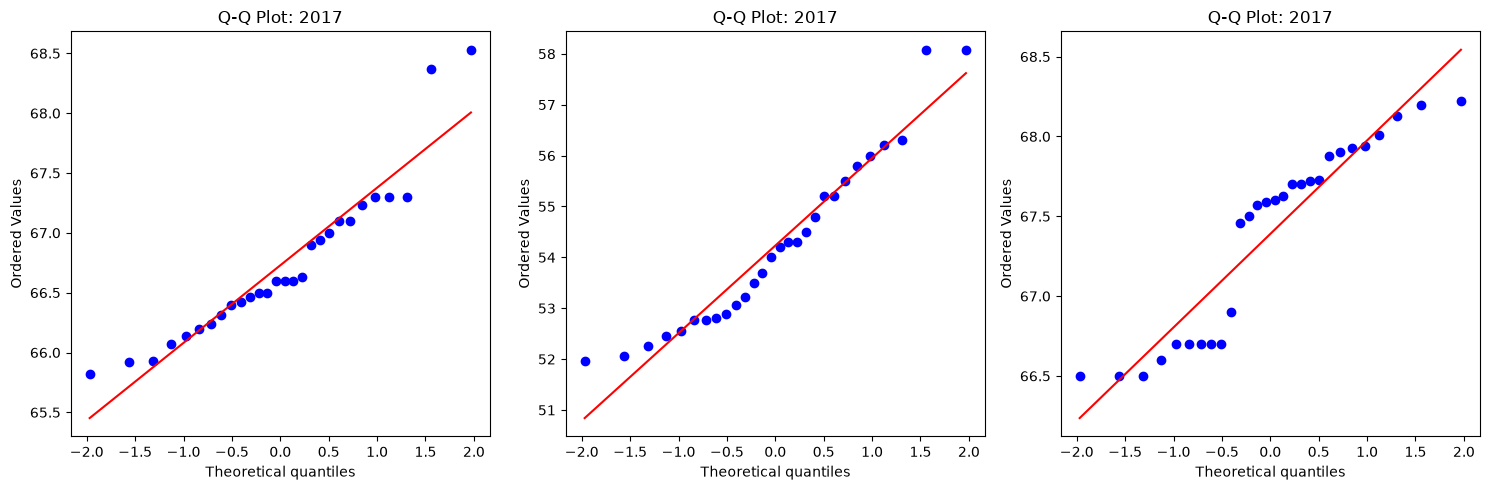

In [118]:
fig, axes = plt.subplots(1, len(regions), figsize=(15, 5))

for ax, region in zip(axes, regions):
    stats.probplot(urbanization[region], dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {year}")
    
plt.tight_layout()
plt.show()

### The equality of the variances

Let's check whether the variances of the samples are equal.

We test the hypothesis $\sigma_{am} = \sigma_{al} = \sigma_{as}$ against the alternative _The variances are not all equal_.

In [ ]:
bartlett_2_result = stats.bartlett(*urbanization.values())
print(f"The p-value obtained from the Bartlett's test: {bartlett_2_result.pvalue:.10f}")

The p-value from the Bartlett's test: 0.0000000056


Because the p-value is extremely small, we reject the null hypothesis of equal variances in favor of the alternative hypothesis. 

Therefore, the assumptions of the standard one-way ANOVA are not satisfied. We will use Alexander–Govern's test instead.

### The equality of means

In [79]:
ag_result = stats.alexandergovern(*urbanization.values())
print(f"The p-value obtained from the Bartlett's test: {ag_result.pvalue}")

The p-value obtained from the Bartlett's test: 9.705237076820532e-35


Since the p-value obtained from Alexander–Govern's test is extremely small, we reject the null hypothesis of equal means. Thus, there is statistically significant evidence that the three population means are not all equal.

### Mean multiple comparisons

In [83]:
tukey_2_result = stats.tukey_hsd(*urbanization.values())
print(tukey_2_result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     12.498     0.000    11.791    13.206
 (0 - 2)     -0.661     0.072    -1.368     0.047
 (1 - 0)    -12.498     0.000   -13.206   -11.791
 (1 - 2)    -13.159     0.000   -13.866   -12.452
 (2 - 0)      0.661     0.072    -0.047     1.368
 (2 - 1)     13.159     0.000    12.452    13.866



In [89]:
print(urbanization.keys())

dict_keys(['Amur Oblast', 'Altai Krai', 'Astrakhan Oblast'])


At the 0.05 significance level, there is a statistically significant difference between the means of Amur Oblast and Altai Krai, as well as between Altai Krai and Astrakhan Oblast.

For Amur Oblast and Astrakhan Oblast, the p-value is 0.072, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of equal means for this pair.

Thus, the results suggest that the mean urbanization coefficient in Altai Krai differs significantly from the means in both Amur Oblast and Astrakhan Oblast, while there is no statistically significant difference between Amur Oblast and Astrakhan Oblast.

# Task 3

Test the hypothesis that the mean value of the urbanization coefficient is equal across the following periods: 2000–2005, 2006–2011, and 2012–2017, for Moscow and Moscow Oblast. Assume that the data are normally distributed.

In [124]:
year_ranges = [range(2000, 2006), range(2006, 2012), range(2012, 2018)]

In [125]:
df_msk_plus = df[df["region"].isin(['Moscow', 'Moscow Oblast'])]

msk = {}

for year_range in year_ranges:
    msk[year_range] = df_msk_plus.loc[df_msk_plus["year"].isin(year_range), "urbanization"]
    print(f"Year range {year_range.start}-{year_range.stop - 1}: \
          \n\t count: {msk[year_range].count()} \
          \n\t count nans: {msk[year_range].isna().sum()} \
          ")

Year range 2000-2005:           
	 count: 12           
	 count nans: 0           
Year range 2006-2011:           
	 count: 12           
	 count nans: 0           
Year range 2012-2017:           
	 count: 12           
	 count nans: 0           


As we see the sample sizes are not all equal. 

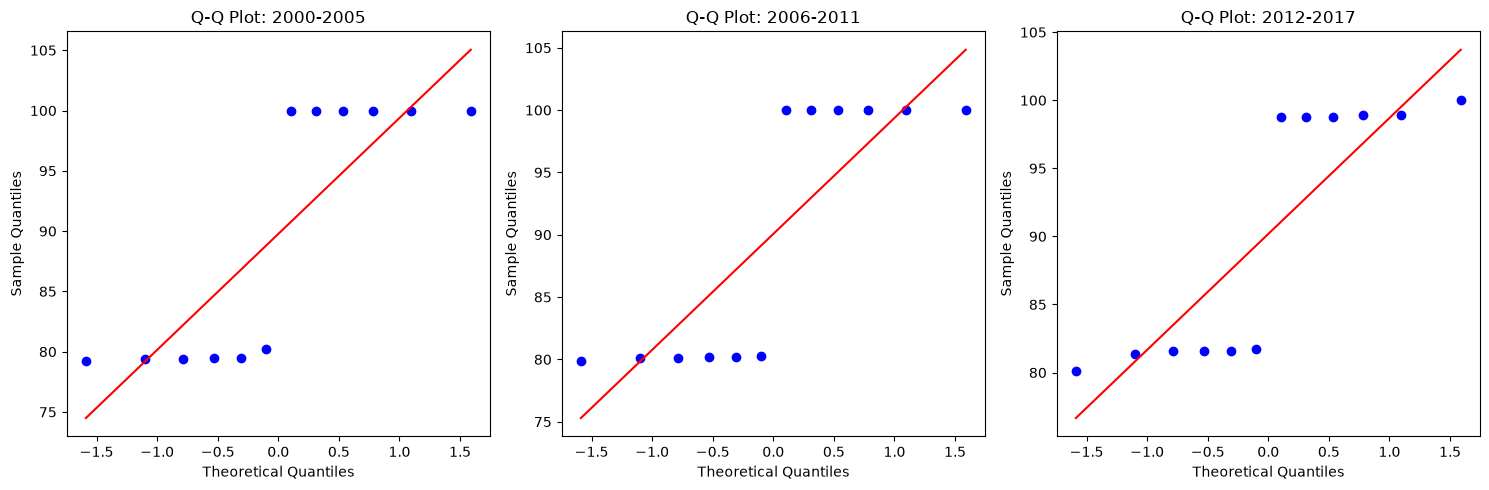

In [126]:
fig, axes = plt.subplots(1, len(year_ranges), figsize=(15, 5))

for ax, year_range in zip(axes, year_ranges):
    stats.probplot(msk[year_range], plot=ax)
    ax.set_title(f"Q-Q Plot: {year_range.start}-{year_range.stop - 1}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

The data is far from normal. There are essentially two clusters of values in each sample.

In [136]:
for year_range in year_ranges:
    print(msk[year_range].describe()[['mean', '50%']])

mean    89.7675
50%     90.1000
Name: urbanization, dtype: float64
mean    90.066667
50%     90.150000
Name: urbanization, dtype: float64
mean    90.183333
50%     90.250000
Name: urbanization, dtype: float64


In [132]:
result = stats.kruskal(*msk.values())
print(result)

KruskalResult(statistic=np.float64(0.38052059367528984), pvalue=np.float64(0.8267439071085827))


The Kruskal–Wallis test yielded a test statistic of 0.381 and a p-value of 0.827. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis. Therefore, there is no statistically significant evidence of differences between the three groups.